In [22]:
import os
import pypsa, pandas as pd, matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False

os.environ["PROJ_LIB"] = "/home/showfhon/pypsa-earth-test/.pixi/envs/default/share/proj"
n0 = pypsa.Network("elec_s_10_ec_lcopt_Co2L-3H.nc")
n1 = pypsa.Network("elec_s_10_ec_lcopt_Co2L-CCL-3H.nc")

#顏色對齊
paper_colors = {
    "CCGT":"#b20101","biomass":"#0c6013","coal":"#707070","nuclear":"#ff9000",
    "hydro":"#08ad97","PHS":"#08ad97","ror":"#4adbc8",
    "offwind-ac":"#6895dd","offwind-dc":"#74c6f2","onwind":"#235ebc",
    "solar":"#f9d002","battery":"#b8ea04","oil":"#262626","load shedding":"#ffffff",
}
nice = {"CCGT":"Combined-Cycle Gas","biomass":"Biomass","coal":"Coal","nuclear":"Nuclear",
        "hydro":"Reservoir & Dam","PHS":"Pumped Hydro Storage","ror":"Run of River",
        "offwind-ac":"Offshore Wind (AC)","offwind-dc":"Offshore Wind (DC)","onwind":"Onshore Wind",
        "solar":"Solar","battery":"Battery Storage","oil":"Oil"}


INFO:matplotlib.font_manager:generated new fontManager
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-CCL-3H.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


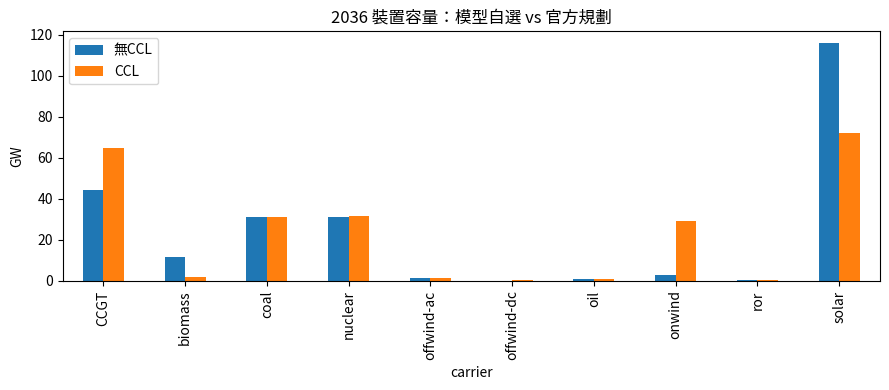

In [23]:
cap = pd.DataFrame({
    "無CCL": n0.generators.groupby("carrier").p_nom_opt.sum(),
    "CCL":   n1.generators.groupby("carrier").p_nom_opt.sum(),
}).drop("load shedding") / 1e3
cap.plot.bar(figsize=(9,4), ylabel="GW", title="2036 裝置容量：模型自選 vs 官方規劃")
plt.tight_layout()

,無CCL,CCL,官方2036,新再生(官方合計204.4)
carrier,,,,
CCGT,90.8,210.5,62.3,
biomass,89.0,13.8,NaN,
coal,126.2,83.3,95.9,
nuclear,207.5,220.3,230.7,
offwind-ac,2.8,2.9,NaN,
offwind-dc,0.0,1.1,NaN,
oil,0.0,0.0,NaN,
onwind,6.0,43.4,NaN,
ror,0.3,0.3,NaN,


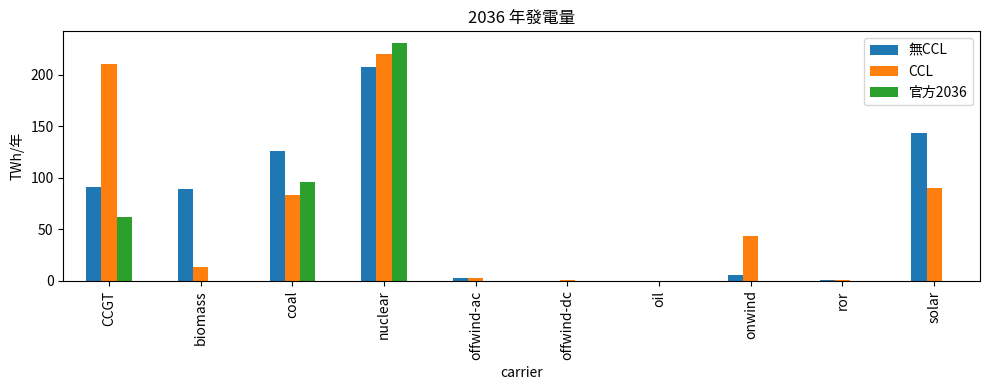

In [24]:
def gen_twh(n):
    g = n.generators_t.p.sum() * n.snapshot_weightings.generators.iloc[0]
    return g.groupby(n.generators.carrier).sum() / 1e6

gen = pd.DataFrame({"無CCL": gen_twh(n0), "CCL": gen_twh(n1)}).drop("load shedding", errors="ignore")
# 官方 2036 發電量（第10次電기본，TWh）
official = pd.Series({"nuclear": 230.7, "coal": 95.9, "CCGT": 62.3,
                      "solar": None, "onwind": None, "offwind-ac": None})
gen["官方2036"] = official
gen["新再生(官方合計204.4)"] = ""
gen.round(1).plot.bar(figsize=(10,4), ylabel="TWh/年", title="2036 年發電量")
plt.tight_layout()
gen.round(1)

In [25]:
def summary(n):
    su = n.storage_units
    bat = su[su.carrier=="battery"]
    w = n.snapshot_weightings.generators.iloc[0]
    vre = n.generators[n.generators.carrier.isin(["solar","onwind","offwind-ac","offwind-dc"])]
    avail = (n.generators_t.p_max_pu[vre.index] * vre.p_nom_opt).sum().sum() * w
    actual = n.generators_t.p[vre.index].sum().sum() * w
    return pd.Series({
        "電池功率 MW": bat.p_nom_opt.sum(),
        "電池容量 MWh": (bat.p_nom_opt*bat.max_hours).sum(),
        "電池放電 TWh": n.storage_units_t.p[bat.index].clip(lower=0).sum().sum()*w/1e6,
        "AC線路 s_nom_opt GW": n.lines.s_nom_opt.sum()/1e3,
        "AC線路擴建 %": (n.lines.s_nom_opt.sum()/n.lines.s_nom.sum()-1)*100,
        "碳排 Mt": n.global_constraints.loc["CO2Limit","constant"]/1e6,
        "碳價 EUR/t": -n.global_constraints.loc["CO2Limit","mu"],
        "VRE棄電率 %": (1-actual/avail)*100,
        "總成本 e10 EUR": n.objective/1e10,
    })

pd.DataFrame({"無CCL": summary(n0), "CCL": summary(n1)}).round(2)

,無CCL,CCL
電池功率 MW,6.86,2.90
電池容量 MWh,41.16,17.38
電池放電 TWh,0.01,0.00
AC線路 s_nom_opt GW,194.42,194.70
AC線路擴建 %,1.55,1.70
碳排 Mt,149.90,149.90
碳價 EUR/t,26.90,26.90
VRE棄電率 %,0.78,0.38
總成本 e10 EUR,1.88,2.28


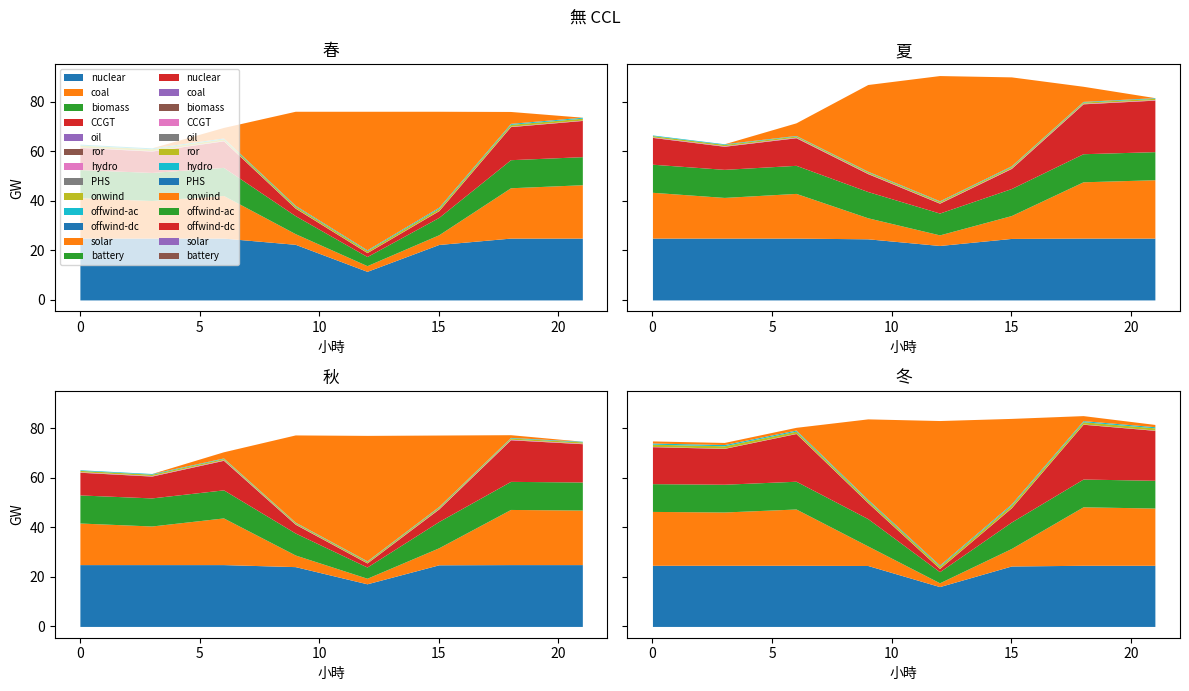

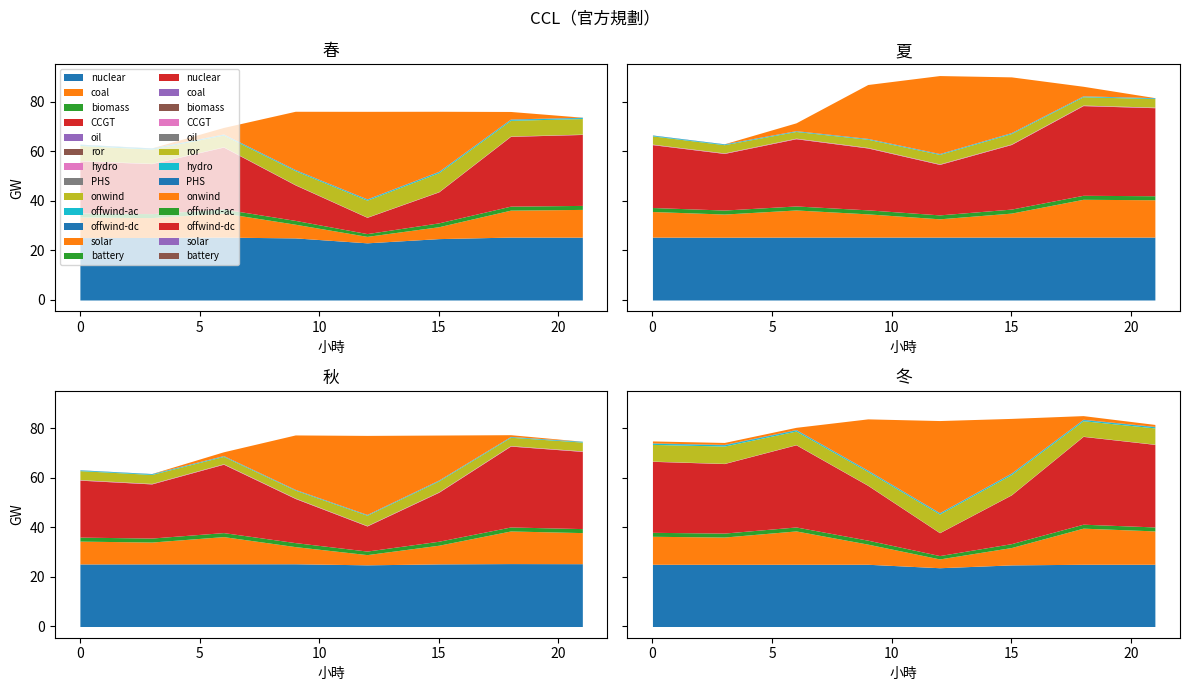

In [26]:
def seasonal(n, title):
    p = n.generators_t.p.T.groupby(n.generators.carrier).sum().T.drop(columns="load shedding", errors="ignore")
    su = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T
    df = pd.concat([p, su], axis=1) / 1e3
    df.index = df.index + pd.Timedelta(hours=9)          # UTC → KST
    m2s = {12:"冬",1:"冬",2:"冬",3:"春",4:"春",5:"春",6:"夏",7:"夏",8:"夏",9:"秋",10:"秋",11:"秋"}
    season = pd.Series(df.index.month, index=df.index).map(m2s)
    order = [c for c in ["nuclear","coal","biomass","CCGT","oil","ror","hydro","PHS",
                         "onwind","offwind-ac","offwind-dc","solar","battery"] if c in df.columns]
    fig, axes = plt.subplots(2, 2, figsize=(12,7), sharey=True)
    for ax, s in zip(axes.flat, ["春","夏","秋","冬"]):
        d = df[season==s]
        d = d.groupby(d.index.hour).mean()[order]
        d.clip(lower=0).plot.area(ax=ax, linewidth=0, legend=False)
        d.clip(upper=0).plot.area(ax=ax, linewidth=0, legend=False)
        ax.set_title(s); ax.set_xlabel("小時"); ax.set_ylabel("GW")
    axes[0,0].legend(loc="upper left", fontsize=7, ncol=2)
    fig.suptitle(title); plt.tight_layout()

seasonal(n0, "無 CCL")
seasonal(n1, "CCL（官方規劃）")

In [27]:
def price(n):
    w = n.snapshot_weightings.generators.iloc[0]
    demand = n.loads_t.p_set.sum().sum() * w                     # MWh
    load = n.loads_t.p_set
    mp = n.buses_t.marginal_price[load.columns.map(n.loads.bus)]
    mp.columns = load.columns
    weighted = (mp * load).sum().sum() / load.sum().sum()        # 負載加權邊際電價
    return pd.Series({
        "總需求 TWh": demand/1e6,
        "平均電價 EUR/MWh (成本/需求，論文Table4定義)": n.objective/demand,
        "負載加權邊際電價 EUR/MWh": weighted,
        "邊際電價 中位數": mp.stack().median(),
        "邊際電價 95百分位": mp.stack().quantile(0.95),
    })

pd.DataFrame({"無CCL": price(n0), "CCL": price(n1), "論文2036": pd.Series({"平均電價 EUR/MWh (成本/需求，論文Table4定義)": 60.9})}).round(1)

,無CCL,CCL,論文2036
平均電價 EUR/MWh (成本/需求，論文Table4定義),28.2,34.2,60.9
總需求 TWh,667.3,667.3,NaN
負載加權邊際電價 EUR/MWh,48.7,54.1,NaN
邊際電價 95百分位,55.5,55.5,NaN
邊際電價 中位數,55.5,55.5,NaN


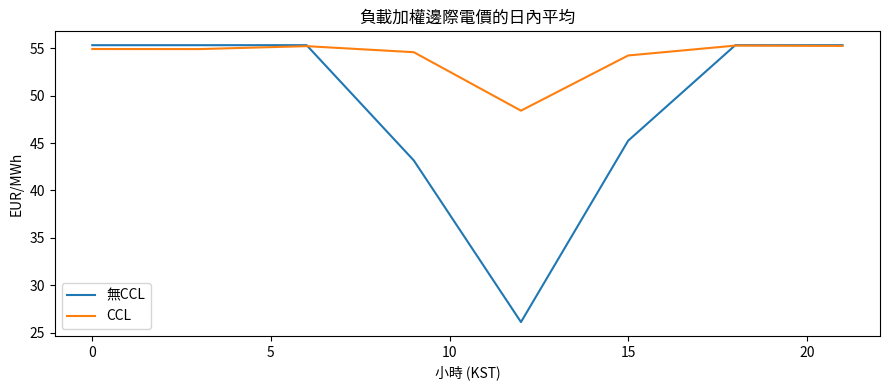

In [28]:
fig, ax = plt.subplots(figsize=(9,4))
for n, lab in [(n0,"無CCL"),(n1,"CCL")]:
    load = n.loads_t.p_set
    mp = n.buses_t.marginal_price[load.columns.map(n.loads.bus)]; mp.columns = load.columns
    s = (mp*load).sum(axis=1)/load.sum(axis=1)
    s.index = s.index + pd.Timedelta(hours=9)
    s.groupby(s.index.hour).mean().plot(ax=ax, label=lab)
ax.set_xlabel("小時 (KST)"); ax.set_ylabel("EUR/MWh"); ax.set_title("負載加權邊際電價的日內平均")
ax.legend(); plt.tight_layout()

/home/showfhon/pypsa-earth-test/.pixi/envs/default/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/showfhon/pypsa-earth-test/.pixi/envs/default/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


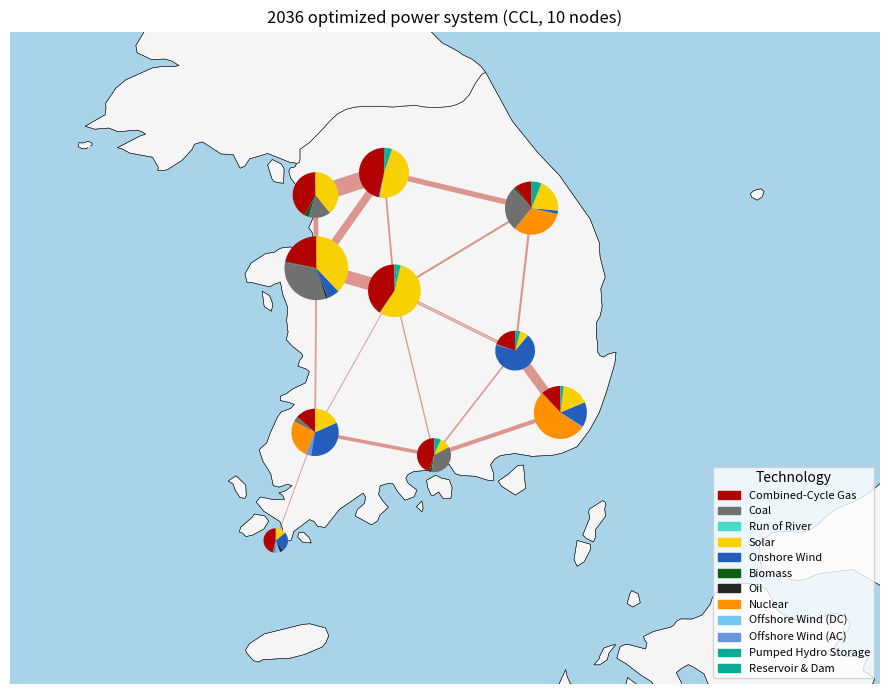

In [33]:
import matplotlib.patches as mpatches, cartopy.crs as ccrs

def fig7(n, title, bus_scale=2e-5, line_scale=3e-4):
    g = n.generators[n.generators.carrier!="load shedding"]
    cap = pd.concat([g.groupby(["bus","carrier"]).p_nom_opt.sum(),
                     n.storage_units.groupby(["bus","carrier"]).p_nom_opt.sum()])
    cap = cap[cap>1]
    lw  = n.lines.s_nom_opt * line_scale
    new = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0) * line_scale
    fig, ax = plt.subplots(figsize=(9,10), subplot_kw={"projection": ccrs.PlateCarree()})
    n.plot(ax=ax, bus_sizes=cap*bus_scale/10, bus_colors=paper_colors,
           line_widths=lw, line_colors="#c0392b", line_alpha=0.5,
           link_widths=n.links.p_nom_opt*line_scale if len(n.links) else 0, link_colors="#27ae60",
           boundaries=[124,132,33,39], geomap=True, color_geomap={"ocean":"#a9d3e8","land":"whitesmoke"})
    n.plot(ax=ax, bus_sizes=0, line_widths=new, line_colors="lightgrey", link_widths=0,
           boundaries=[124,132,33,39], geomap=True)
    handles = [mpatches.Patch(color=paper_colors[c], label=nice.get(c,c)) for c in cap.index.get_level_values(1).unique()]
    ax.legend(handles=handles, loc="lower right", fontsize=8, title="Technology")
    ax.set_title(title)
    plt.tight_layout()

fig7(n1, "2036 optimized power system (CCL, 10 nodes)")

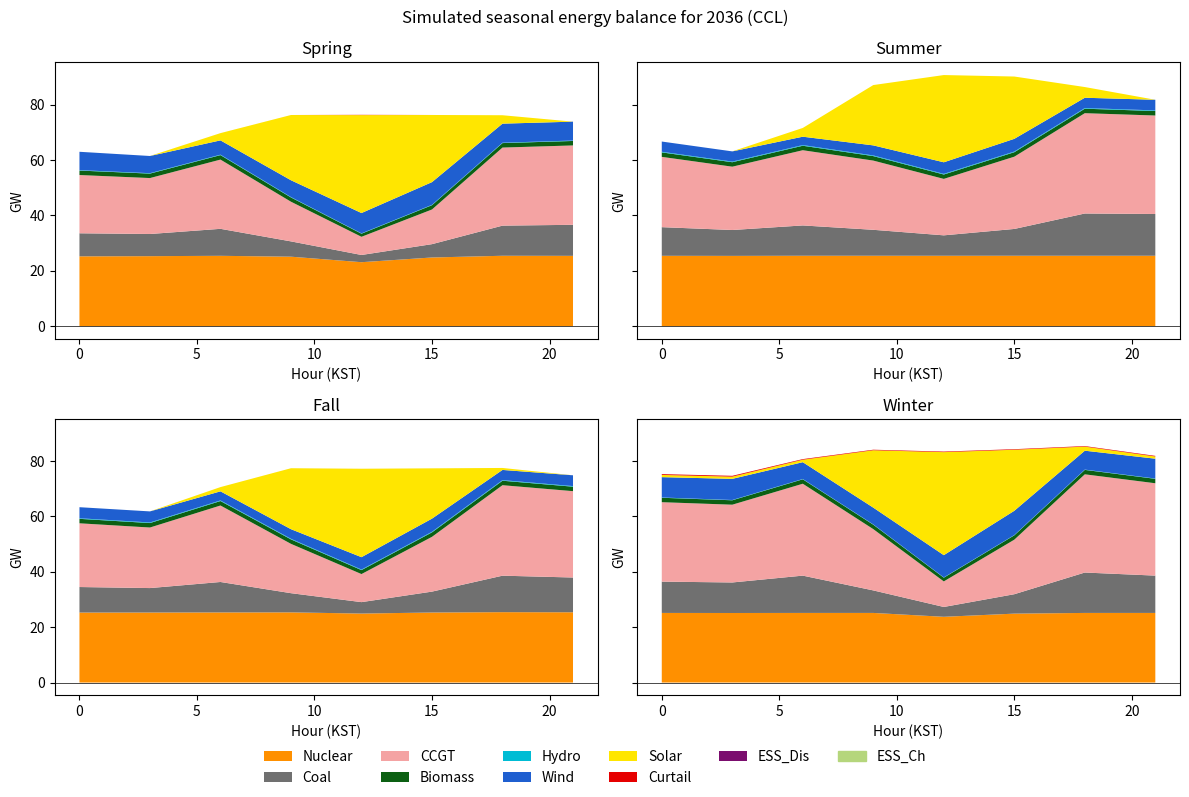

In [30]:
def fig8(n, title):
    w = 1
    g = n.generators[n.generators.carrier!="load shedding"]
    p = n.generators_t.p[g.index].T.groupby(g.carrier).sum().T
    vre = g[g.carrier.isin(["solar","onwind","offwind-ac","offwind-dc"])]
    curtail = ((n.generators_t.p_max_pu[vre.index]*vre.p_nom_opt) - n.generators_t.p[vre.index]).clip(lower=0).sum(axis=1)
    su = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T
    ess = su.sum(axis=1)
    df = pd.DataFrame({"Nuclear":p.get("nuclear",0),"Coal":p.get("coal",0),"CCGT":p.get("CCGT",0),
                       "Biomass":p.get("biomass",0),"Hydro":p.get("ror",0)+su.get("hydro",0).clip(lower=0)+su.get("PHS",0).clip(lower=0),
                       "Wind":p.get("onwind",0)+p.get("offwind-ac",0)+p.get("offwind-dc",0),
                       "Solar":p.get("solar",0),"Curtail":curtail,
                       "ESS_Dis":su.get("battery",0).clip(lower=0),
                       "ESS_Ch":su.get("battery",0).clip(upper=0)+su.get("PHS",0).clip(upper=0)}) / 1e3
    df.index = df.index + pd.Timedelta(hours=9)
    cols = {"Nuclear":"#ff9000","Coal":"#707070","CCGT":"#f4a3a3","Biomass":"#0c6013","Hydro":"#00bcd4",
            "Wind":"#1f5fd0","Solar":"#ffe600","Curtail":"#e60000","ESS_Dis":"#7b0d6e","ESS_Ch":"#b5d67c"}
    m2s = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
    season = pd.Series(df.index.month, index=df.index).map(m2s)
    fig, axes = plt.subplots(2,2, figsize=(12,8), sharey=True)
    for ax, s in zip(axes.flat, ["Spring","Summer","Fall","Winter"]):
        d = df[season==s]; d = d.groupby(d.index.hour).mean()
        pos = d.drop(columns="ESS_Ch"); neg = d[["ESS_Ch"]]
        ax.stackplot(pos.index, pos.T.values, labels=pos.columns, colors=[cols[c] for c in pos.columns], lw=0)
        ax.stackplot(neg.index, neg.T.values, colors=[cols["ESS_Ch"]], lw=0)
        ax.axhline(0, color="k", lw=0.5); ax.set_title(s); ax.set_xlabel("Hour (KST)"); ax.set_ylabel("GW")
    h, l = axes[0,0].get_legend_handles_labels()
    fig.legend(h + [mpatches.Patch(color=cols["ESS_Ch"], label="ESS_Ch")], l + ["ESS_Ch"], loc="lower center", ncol=6, frameon=False)
    fig.suptitle(title); plt.tight_layout(rect=[0,0.05,1,1])

fig8(n1, "Simulated seasonal energy balance for 2036 (CCL)")

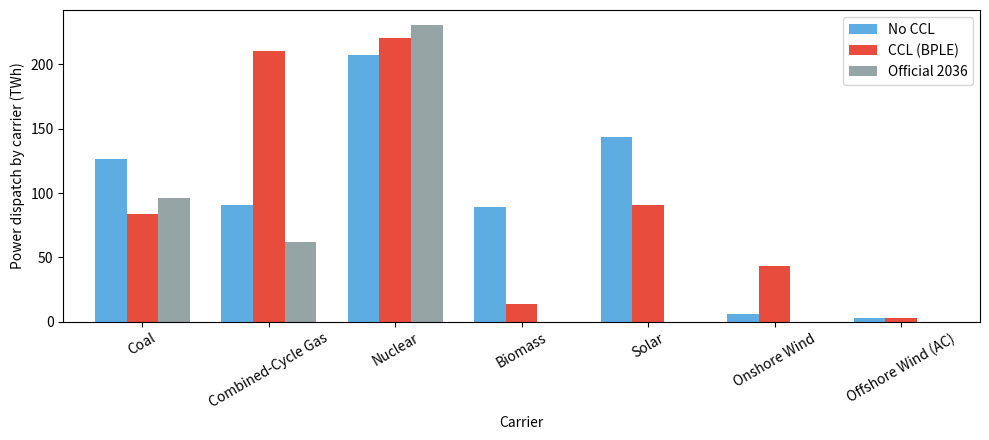

In [31]:
def gen_twh(n):
    g = n.generators_t.p.sum()*n.snapshot_weightings.generators.iloc[0]
    return g.groupby(n.generators.carrier).sum()/1e6
order = ["coal","CCGT","nuclear","biomass","solar","onwind","offwind-ac"]
df = pd.DataFrame({"No CCL": gen_twh(n0), "CCL (BPLE)": gen_twh(n1)}).reindex(order).fillna(0)
df["Official 2036"] = pd.Series({"coal":95.9,"CCGT":62.3,"nuclear":230.7})
ax = df.plot.bar(figsize=(10,4.5), color=["#5dade2","#e74c3c","#95a5a6"], width=0.75)
ax.set_ylabel("Power dispatch by carrier (TWh)"); ax.set_xlabel("Carrier"); ax.set_xticklabels([nice.get(c,c) for c in order], rotation=30)
ax.legend(); plt.tight_layout()